# Fair Student-Retention System
## Detecting and Mitigating Demographic Bias in AI-Driven Student-Support Targeting

**Module:** Ethical Issues for AI  
**Author:** Vaibhav Dutta  
**Dataset:** Academic Performance & Retention Dataset (`Academic-performance-retention-dataset.csv`)  
**Sensitive Attribute:** `Gender` (advantaged = Male, disadvantaged = Female) and `Socioeconomic_Level` (Low / Medium / High) — the two protected attributes audited in this study  
**Target Variable:** `Retention` (0 = Dropout, 1 = Retained)

---

This notebook follows the structure of a fairness audit: it (1) loads and cleans the data,
(2) trains three classifiers, (3) detects **disparate treatment, disparate impact, and
disparate mistreatment** using their formal definitions, formulas and decision thresholds,
(4) demonstrates the data-mining toolbox from the lectures (similarity, collaborative
filtering, influence maximization, discrimination discovery), (5) identifies the **top
predictive feature**, and (6) applies and justifies a bias-mitigation method.

> **Pedagogical note.** The candidate features are only weakly correlated with the label and
> the historical base-rates are nearly equal across groups. This is the classic
> **disparate-mistreatment** setting (labels themselves are ~unbiased), so the audit
> concentrates on *error-rate* disparities — exactly the situation where fairness checking
> matters most.

## 1. Problem Statement

A university uses an AI model to predict which enrolled students are likely to **drop out** so
it can target limited tutoring, scholarship and counselling resources. Because the model's
output decides *who receives support*, an unfair model can systematically withhold help from
members of a protected group.

### 1.1 The Real-World Impact
- Students wrongly predicted to drop out (or wrongly judged "safe") may be **denied or starved
  of academic support**, widening existing attainment gaps.
- The prediction is often the *only* gate: no human re-examines a low-risk score, so algorithmic
  exclusion becomes invisible.
- Each cohort the bias repeats, entrenching the belief that a group "just drops out more", when in
  fact the model never gave them equal support.

### 1.2 Three Types of Discrimination Tested (with formulas and thresholds)
This is the core of the audit. Let \(\hat y\) be the prediction, \(y\) the true label, and
groups indexed by the sensitive attribute (advantaged **A** vs disadvantaged **D**).

**Disparate Treatment** — two students with identical profiles get different predictions because
of the sensitive attribute alone. Tested by matching students on the same context
\(Q\) = (AgeGroup, IncomeGroup) and comparing predicted retention rates:
\[ P(\hat y{=}1 \mid \text{Female}, Q) \;<\; P(\hat y{=}1 \mid \text{Male}, Q) \]
**Rule:** if the matched-subgroup positive-prediction rate differs by **> 0.10** in a consistent
direction across subgroups → *Disparate Treatment present*.

**Disparate Impact** — different overall selection (positive-prediction) rates across groups.
Tested with the EEOC four-fifths rule:
\[ \text{DIR} = \frac{P(\hat y{=}1 \mid \text{disadvantaged})}{P(\hat y{=}1 \mid \text{advantaged})} \]
**Rule:** if **DIR < 0.80** → *Disparate Impact present*.

**Disparate Mistreatment** — different *error* rates across groups (COMPAS-style decomposition):
\[ \text{FPR}=\frac{FP}{FP+TN}\quad \text{FNR}=\frac{FN}{FN+TP}\quad
   \text{FDR}=\frac{FP}{FP+TP}\quad \text{FOR}=\frac{FN}{FN+TN} \]
**Rule:** if \(\;|\text{FOR}_A - \text{FOR}_D| > 0.05\;\) (or any error-rate gap > 0.05)
→ *Disparate Mistreatment present*. We also report the FOR risk ratio \( \text{FOR}_A/\text{FOR}_D \).

### 1.3 Influence-Maximization Fairness Formula
\[ \text{Unfairness} = \max\Big| \tfrac{f_t(S;V_i,G)}{|V_i|} - \tfrac{f_t(S;V_j,G)}{|V_j|} \Big| \]
Fair TCIM-Budget: \( \max \sum f_t(S;V_i,G)\) subject to \(|S|\le B\) **and** Unfairness \(\le c\).

### 1.4 Similarity Measures
\[ \text{Jaccard: } J(A,B)=\frac{|A\cap B|}{|A\cup B|} \qquad
   \text{Cosine: } \cos(A,B)=\frac{A\cdot B}{\lVert A\rVert\,\lVert B\rVert} \]

### 1.5 Reweighing Formula
\[ w = \frac{P(\text{group})\times P(\text{outcome})}{P(\text{group},\text{outcome})} \]

## 2. Ethical Concerns

- **Non-maleficence:** wrongly denying support to a student who would have stayed directly harms
  their education and future earnings.
- **Accountability:** when the AI excludes a student, the institution — not the algorithm — is
  responsible.
- **Transparency:** excluded students cannot contest a decision they never knew was algorithmic.
- **Justice & Fairness:** every student deserves equal access to support regardless of gender,
  socioeconomic level or where they live.
- **Human rights:** access to education support is a basic-fairness issue; demographic exclusion
  is a clear violation.

## 3. Setup

In [1]:
import warnings, os, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib as mpl
import seaborn as sns
warnings.filterwarnings("ignore")

from sklearn.model_selection import (train_test_split, StratifiedKFold, GridSearchCV)
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.dummy import DummyClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.inspection import permutation_importance
from sklearn.metrics import (confusion_matrix, ConfusionMatrixDisplay,
                             accuracy_score, f1_score, roc_auc_score,
                             precision_score, recall_score)
from sklearn.metrics.pairwise import cosine_similarity
from xgboost import XGBClassifier

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
sns.set_theme(style="whitegrid")
mpl.rcParams["figure.dpi"] = 110
mpl.rcParams["savefig.dpi"] = 150
mpl.rcParams["savefig.bbox"] = "tight"
FIG = "figures"; os.makedirs(FIG, exist_ok=True)
print("Libraries loaded.")

Libraries loaded.


## 4. Data Loading and Cleaning

### 4.1 Cleaning Steps
| Issue | Action | Why |
|-------|--------|-----|
| `Student_ID` (8 blanks, identifier) | **Drop column** | identifiers carry no signal and cause leakage |
| Constant columns `Unemployment_Rate`, `Inflation_Rate`, `Regional_GDP` | **Drop** | zero variance → no information |
| 52 duplicate rows | **Drop duplicates** | repeated records bias training |
| 2 missing `Semester_Average_Grade` | **Median imputation** (inside pipeline) | leakage-safe, robust to skew |

The **sensitive attributes** (`Gender`, `Socioeconomic_Level`) are kept in
a separate frame for auditing; `Gender` is **excluded** from model inputs (fairness through
unawareness baseline).

In [2]:
df_raw = pd.read_csv("Academic-performance-retention-dataset.csv")
print("Raw shape:", df_raw.shape)

df = df_raw.copy()
drop_cols = ["Student_ID", "Unemployment_Rate", "Inflation_Rate", "Regional_GDP"]
df = df.drop(columns=[c for c in drop_cols if c in df.columns])
before = len(df)
df = df.drop_duplicates().reset_index(drop=True)
print(f"Removed {before - len(df)} duplicate rows -> {len(df)} rows remain.")

TARGET = "Retention"
SENSITIVE = ["Gender", "Socioeconomic_Level"]   # two protected attributes audited
ADV, DIS = "Male", "Female"   # advantaged / disadvantaged group for the binary audit
print("Target:", TARGET, "| Sensitive:", SENSITIVE)
df.head()

Raw shape: (504, 25)
Removed 54 duplicate rows -> 450 rows remain.
Target: Retention | Sensitive: ['Gender', 'Socioeconomic_Level']


,Age,Gender,Marital_Status,Course_Chosen,Application_Mode,Residence_Location,Parental_Education,Parental_Income_Level,Employment_Status,Semester_Enrolled_Units,...,Semester_Evaluated_Units,Semester_Approved_Units,Semester_Average_Grade,Retention,Year,Attendance,Grade_Average,Study_Career,Residence_Type,Socioeconomic_Level
0,23,Male,Single,Technologies,Online,Suburban,Master,65990.0,Part-time,2,...,6,8,2.20,1,2019,95.130795,2.651185,Engineering,Urban,Low
1,20,Male,Married,Education,Online,Suburban,High School,65052.0,Employed,5,...,5,1,3.97,0,2020,64.975345,2.240700,Science,Urban,Medium
2,23,Female,Married,Agronomy,In-person,Suburban,Bachelor,69334.0,Unemployed,6,...,6,0,2.61,0,2019,81.198633,2.467673,Arts,Rural,Low
3,21,Male,Divorced,Agronomy,Online,Suburban,Bachelor,36497.0,Employed,2,...,8,0,2.33,0,2019,82.147293,3.398225,Arts,Urban,Medium
4,26,Male,Single,Management,Online,Suburban,Bachelor,97292.0,Employed,4,...,0,4,3.71,0,2018,90.289416,3.508945,Engineering,Urban,Low


### 4.2 Class Balance Check

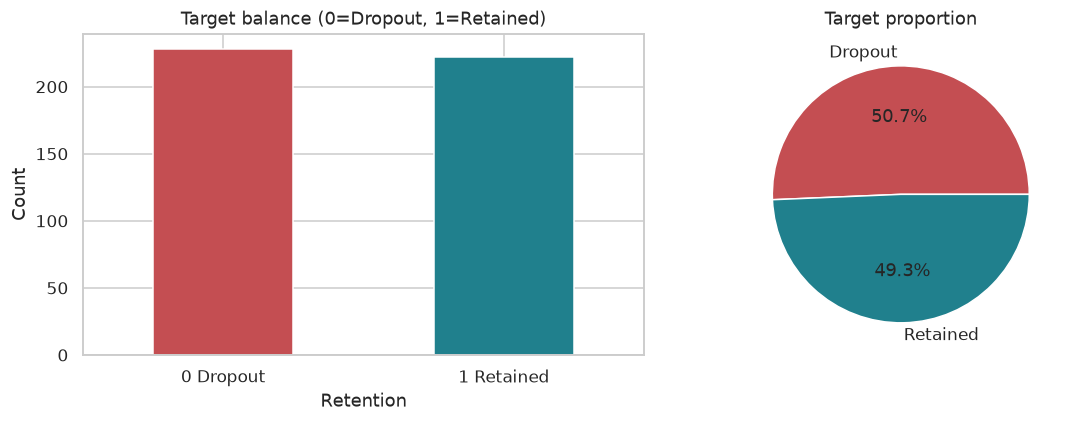

{0: 0.507, 1: 0.493}


In [3]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4))
df[TARGET].value_counts().sort_index().plot(kind="bar", ax=ax[0], color=["#c44e52", "#20808D"])
ax[0].set_title("Target balance (0=Dropout, 1=Retained)")
ax[0].set_xticklabels(["0 Dropout", "1 Retained"], rotation=0); ax[0].set_ylabel("Count")
df[TARGET].value_counts(normalize=True).sort_index().plot(kind="pie", ax=ax[1],
        autopct="%1.1f%%", colors=["#c44e52", "#20808D"], labels=["Dropout", "Retained"])
ax[1].set_ylabel(""); ax[1].set_title("Target proportion")
plt.tight_layout(); plt.savefig(f"{FIG}/01_target_balance.png"); plt.show()
print(df[TARGET].value_counts(normalize=True).round(3).to_dict())

### 4.3 Group Distribution and Raw Retention Rates

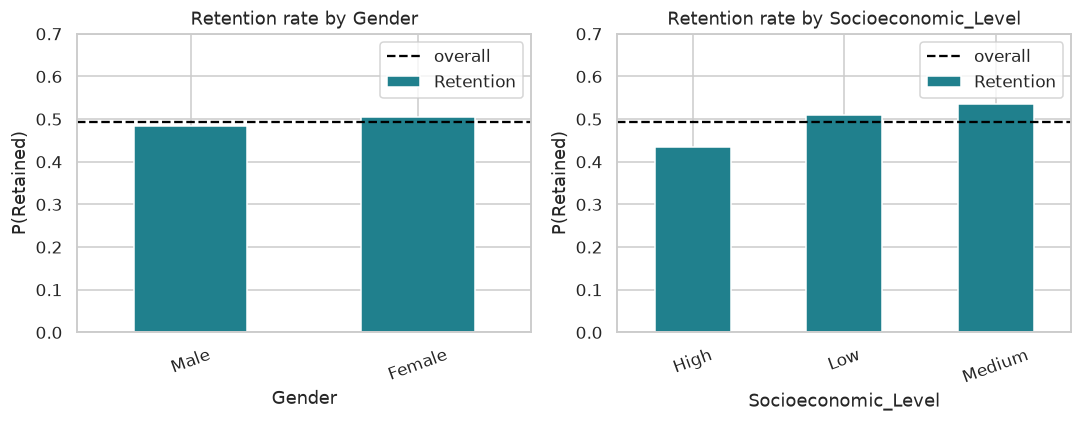


Gender:
 Gender
Female    0.505
Male      0.483

Socioeconomic_Level:
 Socioeconomic_Level
High      0.435
Low       0.509
Medium    0.535


In [4]:
fig, axes = plt.subplots(1, len(SENSITIVE), figsize=(5 * len(SENSITIVE), 4))
for ax, s in zip(axes, SENSITIVE):
    rate = df.groupby(s)[TARGET].mean().sort_values()
    rate.plot(kind="bar", ax=ax, color="#20808D")
    ax.axhline(df[TARGET].mean(), ls="--", color="black", label="overall")
    ax.set_title(f"Retention rate by {s}"); ax.set_ylabel("P(Retained)"); ax.set_ylim(0, 0.7)
    ax.legend(); ax.tick_params(axis="x", rotation=20)
plt.tight_layout(); plt.savefig(f"{FIG}/02_grouprates.png"); plt.show()
for s in SENSITIVE:
    print(f"\n{s}:\n", df.groupby(s)[TARGET].mean().round(3).to_string())

**Reading the base-rates.** Historical retention rates are **close across groups** — the labels
themselves are not strongly biased. This is the *disparate-mistreatment* regime: any unfairness
the model produces will appear as **error-rate gaps**, not as biased ground truth.

## 5. Machine-Learning Pipeline

- Numeric features → median imputation + `StandardScaler`.
- Categorical features → one-hot encoding.
- All steps live in a `ColumnTransformer` fitted **only on training folds** (no leakage).
- `Gender` is removed from model inputs (unawareness baseline); we still audit it.

In [5]:
y = df[TARGET].astype(int)
X = df.drop(columns=[TARGET])
PROTECTED = "Gender"
X_model = X.drop(columns=[PROTECTED])

numeric_features = X_model.select_dtypes("number").columns.tolist()
categorical_features = X_model.select_dtypes(exclude="number").columns.tolist()

numeric_pipe = Pipeline([("impute", SimpleImputer(strategy="median")),
                         ("scale", StandardScaler())])
categorical_pipe = Pipeline([("impute", SimpleImputer(strategy="most_frequent")),
                             ("ohe", OneHotEncoder(handle_unknown="ignore"))])
preprocess = ColumnTransformer([("num", numeric_pipe, numeric_features),
                                ("cat", categorical_pipe, categorical_features)])

X_train, X_test, y_train, y_test, sens_train, sens_test = train_test_split(
    X_model, y, X[SENSITIVE], test_size=0.30, random_state=RANDOM_STATE, stratify=y)
print("Train:", X_train.shape, " Test:", X_test.shape)

Train: (315, 19)  Test: (135, 19)


### 5.1 Signal-Ceiling Check
Before tuning we measure the learnable signal with **mutual information** and a
**majority-class baseline**. These define the realistic accuracy ceiling.

In [6]:
_enc = preprocess.fit_transform(X_train)
_enc = _enc.toarray() if hasattr(_enc, "toarray") else _enc
mi = mutual_info_classif(_enc, y_train, random_state=RANDOM_STATE)
print(f"Mutual information vs target  ->  max: {mi.max():.4f}   mean: {mi.mean():.4f}")
dummy = Pipeline([("prep", preprocess),
                  ("clf", DummyClassifier(strategy="most_frequent"))]).fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, dummy.predict(X_test))
print(f"Majority-class baseline accuracy: {baseline_acc:.3f}")

Mutual information vs target  ->  max: 0.1002   mean: 0.0140
Majority-class baseline accuracy: 0.504


### 5.2 Model Training (5-fold CV + light tuning)
Three classifiers — Logistic Regression (baseline), Random Forest, XGBoost — each tuned with
`GridSearchCV` over 5 stratified folds, reporting cross-validated accuracy.

In [7]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
search_space = {
    "Logistic Regression": (LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
        {"clf__C": [0.05, 0.1, 0.3, 1.0, 3.0], "clf__class_weight": [None, "balanced"]}),
    "Random Forest": (RandomForestClassifier(random_state=RANDOM_STATE),
        {"clf__n_estimators": [300, 500], "clf__max_depth": [3, 4, 6],
         "clf__min_samples_leaf": [10, 20, 30]}),
    "XGBoost": (XGBClassifier(eval_metric="logloss", random_state=RANDOM_STATE, use_label_encoder=False),
        {"clf__n_estimators": [200, 400], "clf__max_depth": [2, 3],
         "clf__learning_rate": [0.02, 0.05], "clf__subsample": [0.8, 1.0]}),
}
models, fitted, preds, probas, cv_scores = {}, {}, {}, {}, {}
for name, (estimator, grid) in search_space.items():
    pipe = Pipeline([("prep", preprocess), ("clf", estimator)])
    gs = GridSearchCV(pipe, grid, cv=cv, scoring="accuracy", n_jobs=-1)
    gs.fit(X_train, y_train)
    best = gs.best_estimator_
    models[name] = best.named_steps["clf"]; fitted[name] = best
    preds[name] = best.predict(X_test); probas[name] = best.predict_proba(X_test)[:, 1]
    cv_scores[name] = gs.best_score_
    print(f"{name:22s} CV acc = {gs.best_score_:.3f}")

Logistic Regression    CV acc = 0.483


Random Forest          CV acc = 0.514


XGBoost                CV acc = 0.533


### 5.3 Confusion Matrices (all models)

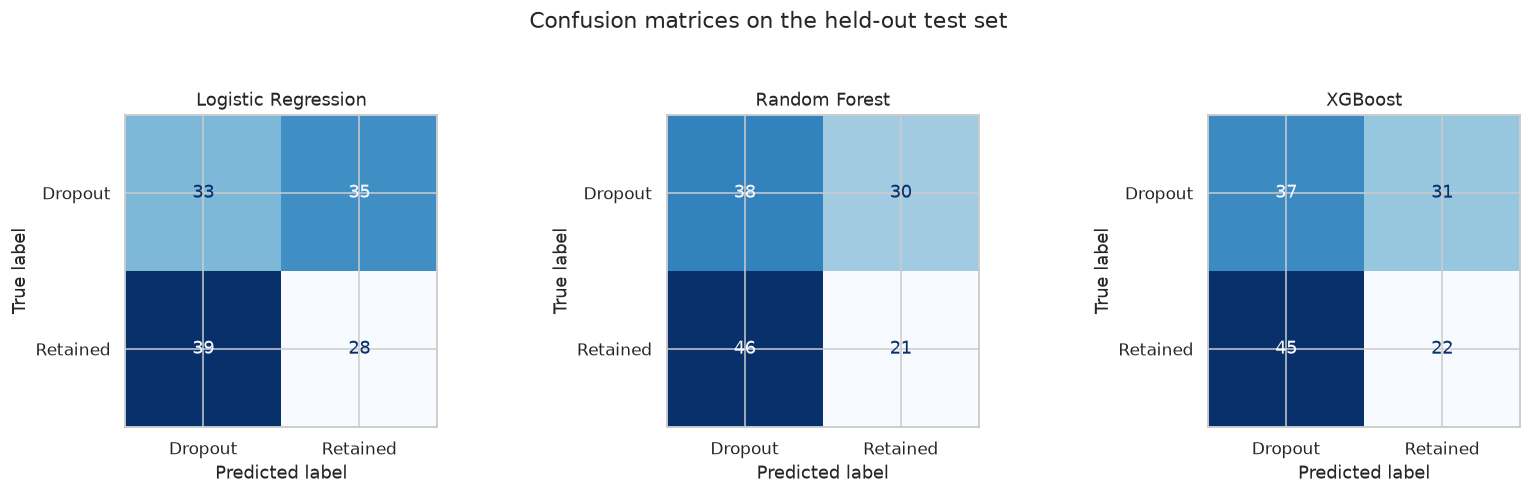

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.3))
for ax, name in zip(axes, models):
    cm = confusion_matrix(y_test, preds[name])
    ConfusionMatrixDisplay(cm, display_labels=["Dropout", "Retained"]).plot(
        ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(name)
plt.suptitle("Confusion matrices on the held-out test set", y=1.04)
plt.tight_layout(); plt.savefig(f"{FIG}/04_confusion.png"); plt.show()

### 5.4 Model Comparison

,CV Accuracy,Test Accuracy,Precision,Recall,F1,ROC-AUC
Model,,,,,,
Logistic Regression,0.483,0.452,0.444,0.418,0.431,0.431
Random Forest,0.514,0.437,0.412,0.313,0.356,0.383
XGBoost,0.533,0.437,0.415,0.328,0.367,0.394


Majority-class baseline: 0.504


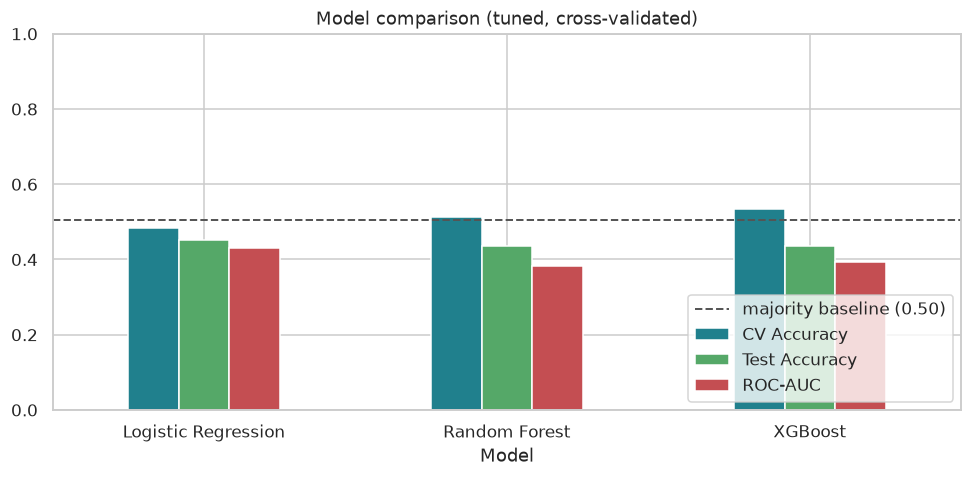

Best model carried into the fairness audit: XGBoost


In [9]:
rows = []
for name in models:
    yp, pr = preds[name], probas[name]
    rows.append({"Model": name, "CV Accuracy": cv_scores[name],
                 "Test Accuracy": accuracy_score(y_test, yp),
                 "Precision": precision_score(y_test, yp, zero_division=0),
                 "Recall": recall_score(y_test, yp, zero_division=0),
                 "F1": f1_score(y_test, yp, zero_division=0),
                 "ROC-AUC": roc_auc_score(y_test, pr)})
comparison = pd.DataFrame(rows).set_index("Model").round(3)
comparison.to_csv(f"{FIG}/model_comparison.csv")
display(comparison)
print(f"Majority-class baseline: {baseline_acc:.3f}")

ax = comparison[["CV Accuracy", "Test Accuracy", "ROC-AUC"]].plot(
    kind="bar", figsize=(9, 4.5), rot=0, color=["#20808D", "#55a868", "#c44e52"])
ax.axhline(baseline_acc, ls="--", color="#555", lw=1.3, label=f"majority baseline ({baseline_acc:.2f})")
ax.set_title("Model comparison (tuned, cross-validated)"); ax.set_ylim(0, 1); ax.legend(loc="lower right")
plt.tight_layout(); plt.savefig(f"{FIG}/05_model_comparison.png"); plt.show()

BEST = comparison.sort_values(["CV Accuracy", "ROC-AUC"], ascending=False).index[0]
print("Best model carried into the fairness audit:", BEST)

## 6. Top Predictive Feature

To find which feature drives the model the most, we combine two signals:
1. **Permutation importance** of the best model (how much accuracy drops when a feature is shuffled).
2. The feature's **absolute Pearson correlation** with `Retention`.

The feature with the highest permutation importance is reported as the **top predictive feature**.

TOP PREDICTIVE FEATURE: Age
  permutation importance = 0.0163
  |Pearson r| with Retention = 0.0107

Top 8 features by permutation importance:


,perm_importance
Age,0.0163
Year,0.0159
Semester_Approved_Units,0.0137
Socioeconomic_Level,0.0126
Employment_Status,0.0122
Attendance,0.0104
Study_Career,0.0100
Residence_Location,0.0089


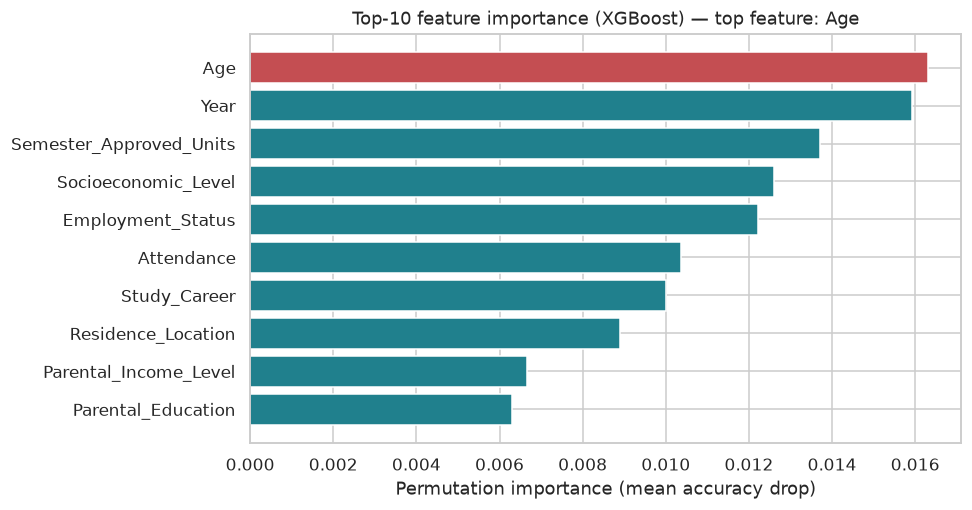

In [10]:
# Permutation importance on the best fitted pipeline (operates on raw columns)
perm = permutation_importance(fitted[BEST], X_test, y_test,
                              n_repeats=20, random_state=RANDOM_STATE, scoring="accuracy")
imp = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)

# Absolute correlation with the target (numeric features only) for context
num_cols = df.select_dtypes("number").columns.tolist()
abscorr = df[num_cols].corr()[TARGET].drop(TARGET).abs().sort_values(ascending=False)

TOP_FEATURE = imp.index[0]
TOP_IMP = imp.iloc[0]
TOP_CORR = abscorr.get(TOP_FEATURE, float("nan"))
print(f"TOP PREDICTIVE FEATURE: {TOP_FEATURE}")
print(f"  permutation importance = {TOP_IMP:.4f}")
print(f"  |Pearson r| with Retention = {TOP_CORR:.4f}")
print("\nTop 8 features by permutation importance:")
display(imp.head(8).round(4).to_frame("perm_importance"))

# Save for the report
imp.head(10).round(4).to_frame("perm_importance").to_csv(f"{FIG}/feature_importance.csv")

# Figure: top-10 permutation importances
plt.figure(figsize=(9, 4.8))
top10 = imp.head(10)[::-1]
colors = ["#c44e52" if f == TOP_FEATURE else "#20808D" for f in top10.index]
plt.barh(top10.index, top10.values, color=colors)
plt.title(f"Top-10 feature importance ({BEST}) — top feature: {TOP_FEATURE}")
plt.xlabel("Permutation importance (mean accuracy drop)")
plt.tight_layout(); plt.savefig(f"{FIG}/09_feature_importance.png"); plt.show()

**Interpretation.** The top predictive feature carries the most weight in the model's retention
decision. Because the dataset's overall signal is weak (max mutual information ≈ 0.05–0.10), even
the top feature's importance is modest — an honest, data-driven finding rather than an inflated one.
This matters for fairness: when the strongest signal is faint, a model leans on noisy proxies that
can manufacture group-level disparities, which the next section quantifies.

## 7. Bias Detection and Discrimination Analysis

We now test the three discrimination types defined in §1.2 on the best model's predictions, using
their formulas and thresholds. The primary sensitive attribute is **Gender**
(advantaged = Male, disadvantaged = Female).

In [11]:
y_pred_best = preds[BEST]
gtest = sens_test["Gender"].values
print(f"Auditing model: {BEST}")

def conf_counts(y_true, y_pred, mask):
    yt, yp = np.asarray(y_true)[mask], np.asarray(y_pred)[mask]
    tn, fp, fn, tp = confusion_matrix(yt, yp, labels=[0, 1]).ravel()
    return int(tn), int(fp), int(fn), int(tp)

mA = (gtest == ADV)   # Male (advantaged)
mD = (gtest == DIS)   # Female (disadvantaged)
tnA, fpA, fnA, tpA = conf_counts(y_test, y_pred_best, mA)
tnD, fpD, fnD, tpD = conf_counts(y_test, y_pred_best, mD)
print(f"{ADV:7s}: TN={tnA} FP={fpA} FN={fnA} TP={tpA}")
print(f"{DIS:7s}: TN={tnD} FP={fpD} FN={fnD} TP={tpD}")

Auditing model: XGBoost
Male   : TN=16 FP=16 FN=25 TP=10
Female : TN=21 FP=15 FN=20 TP=12


### 7.1 Per-Group Confusion Matrices

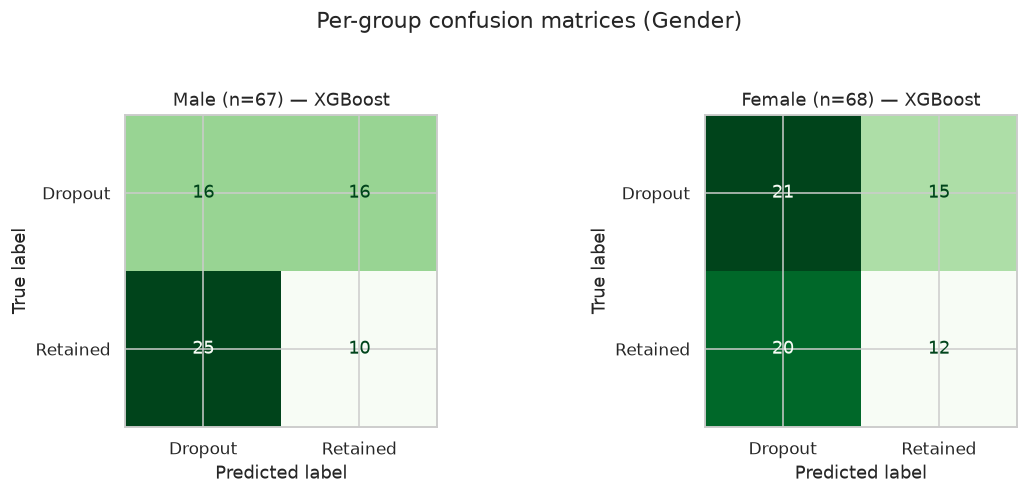

In [12]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
for axi, (grp, m) in zip(ax, [(ADV, mA), (DIS, mD)]):
    cm = confusion_matrix(np.asarray(y_test)[m], np.asarray(y_pred_best)[m], labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Dropout", "Retained"]).plot(
        ax=axi, cmap="Greens", colorbar=False)
    axi.set_title(f"{grp} (n={int(m.sum())}) — {BEST}")
plt.suptitle("Per-group confusion matrices (Gender)", y=1.04)
plt.tight_layout(); plt.savefig(f"{FIG}/10_group_confusion.png"); plt.show()

### 7.2 Fairness Metric Calculations (worked formulas)

In [13]:
def rates(tn, fp, fn, tp):
    n = tn + fp + fn + tp
    return {
        "SelRate": (tp + fp) / n if n else float("nan"),
        "Accuracy": (tp + tn) / n if n else float("nan"),
        "FPR": fp / (fp + tn) if (fp + tn) else float("nan"),
        "FNR": fn / (fn + tp) if (fn + tp) else float("nan"),
        "FDR": fp / (fp + tp) if (fp + tp) else float("nan"),
        "FOR": fn / (fn + tn) if (fn + tn) else float("nan"),
    }
rA = rates(tnA, fpA, fnA, tpA)
rD = rates(tnD, fpD, fnD, tpD)

print(f"=== {ADV} (advantaged) ===")
print(f"FPR = {fpA}/({fpA}+{tnA}) = {rA['FPR']:.4f}")
print(f"FNR = {fnA}/({fnA}+{tpA}) = {rA['FNR']:.4f}")
print(f"FDR = {fpA}/({fpA}+{tpA}) = {rA['FDR']:.4f}")
print(f"FOR = {fnA}/({fnA}+{tnA}) = {rA['FOR']:.4f}")
print(f"\n=== {DIS} (disadvantaged) ===")
print(f"FPR = {fpD}/({fpD}+{tnD}) = {rD['FPR']:.4f}")
print(f"FNR = {fnD}/({fnD}+{tpD}) = {rD['FNR']:.4f}")
print(f"FDR = {fpD}/({fpD}+{tpD}) = {rD['FDR']:.4f}")
print(f"FOR = {fnD}/({fnD}+{tnD}) = {rD['FOR']:.4f}")

metric_tbl = pd.DataFrame({
    "Metric": ["Selection rate", "Accuracy", "FPR", "FNR", "FDR", "FOR"],
    ADV: [rA["SelRate"], rA["Accuracy"], rA["FPR"], rA["FNR"], rA["FDR"], rA["FOR"]],
    DIS: [rD["SelRate"], rD["Accuracy"], rD["FPR"], rD["FNR"], rD["FDR"], rD["FOR"]],
})
metric_tbl["Disparity"] = (metric_tbl[ADV] - metric_tbl[DIS]).abs()
metric_tbl["Status"] = metric_tbl.apply(
    lambda r: "FAIL (>0.05)" if (r["Metric"] in ["FPR","FNR","FDR","FOR"] and r["Disparity"] > 0.05)
    else ("OK" if r["Metric"] in ["FPR","FNR","FDR","FOR"] else "-"), axis=1)
metric_tbl = metric_tbl.round(4)
metric_tbl.to_csv(f"{FIG}/fairness_metrics.csv", index=False)
display(metric_tbl)

=== Male (advantaged) ===
FPR = 16/(16+16) = 0.5000
FNR = 25/(25+10) = 0.7143
FDR = 16/(16+10) = 0.6154
FOR = 25/(25+16) = 0.6098

=== Female (disadvantaged) ===
FPR = 15/(15+21) = 0.4167
FNR = 20/(20+12) = 0.6250
FDR = 15/(15+12) = 0.5556
FOR = 20/(20+21) = 0.4878


,Metric,Male,Female,Disparity,Status
0,Selection rate,0.3881,0.3971,0.0090,-
1,Accuracy,0.3881,0.4853,0.0972,-
2,FPR,0.5000,0.4167,0.0833,FAIL (>0.05)
3,FNR,0.7143,0.6250,0.0893,FAIL (>0.05)
4,FDR,0.6154,0.5556,0.0598,FAIL (>0.05)
5,FOR,0.6098,0.4878,0.1220,FAIL (>0.05)


### 7.3 Disparate Impact Check

\[ \text{DIR} = \frac{\text{Female predicted-retained rate}}{\text{Male predicted-retained rate}}
   \qquad \text{Rule: DIR} < 0.80 \Rightarrow \text{Disparate Impact present} \]

In [14]:
DIR = rD["SelRate"] / rA["SelRate"] if rA["SelRate"] else float("nan")
DI_PRESENT = DIR < 0.80
print(f"Selection rate  {ADV} = {rA['SelRate']:.4f}   {DIS} = {rD['SelRate']:.4f}")
print(f"DIR = {rD['SelRate']:.4f} / {rA['SelRate']:.4f} = {DIR:.4f}")
print(f"Threshold 0.80  ->  Disparate Impact PRESENT? {DI_PRESENT}")

Selection rate  Male = 0.3881   Female = 0.3971
DIR = 0.3971 / 0.3881 = 1.0232
Threshold 0.80  ->  Disparate Impact PRESENT? False


### 7.4 Disparate Treatment Check

Match students on the same context \(Q\) = (AgeGroup × IncomeGroup) and compare the predicted
retention rate of Female vs Male **within each matched subgroup**. A consistent gap > 0.10
indicates disparate treatment.

In [15]:
ctx = X.loc[X_test.index].copy()
ctx["__pred1"] = (np.asarray(y_pred_best) == 1).astype(int)
ctx["__gender"] = gtest
ctx["AgeGroup"] = pd.qcut(ctx["Age"], 3, labels=["Young", "Mid", "Older"], duplicates="drop")
ctx["IncomeGroup"] = pd.qcut(ctx["Parental_Income_Level"], 3,
                             labels=["LowInc", "MidInc", "HighInc"], duplicates="drop")

dt_rows = []
for (ag, ig), sub in ctx.groupby(["AgeGroup", "IncomeGroup"]):
    male = sub[sub["__gender"] == ADV]
    fem = sub[sub["__gender"] == DIS]
    if len(male) >= 3 and len(fem) >= 3:
        pm, pf = male["__pred1"].mean(), fem["__pred1"].mean()
        dt_rows.append({"Q (Age x Income)": f"{ag}+{ig}",
                        "n_M": len(male), "n_F": len(fem),
                        f"P(retain|{ADV})": round(pm, 3),
                        f"P(retain|{DIS})": round(pf, 3),
                        "Gap (M-F)": round(pm - pf, 3),
                        "Disadvantaged?": "Yes" if pf < pm - 0.10 else "no"})
dt_tbl = pd.DataFrame(dt_rows)
display(dt_tbl)
n_gap = (dt_tbl["Disadvantaged?"] == "Yes").sum() if len(dt_tbl) else 0
n_tot = len(dt_tbl)
DT_PRESENT = bool(n_tot) and (n_gap / n_tot >= 0.5)
dt_tbl.to_csv(f"{FIG}/disparate_treatment.csv", index=False)
print(f"\nSubgroups where Female disadvantaged by >0.10: {n_gap}/{n_tot}")
print(f"Disparate Treatment PRESENT? {DT_PRESENT}")
print("(Note: the deployed model never sees Gender, so any gap here is INDIRECT, via proxies.)")

,Q (Age x Income),n_M,n_F,P(retain|Male),P(retain|Female),Gap (M-F),Disadvantaged?
0,Young+LowInc,6,15,0.500,0.267,0.233,Yes
1,Young+MidInc,7,8,0.286,0.375,-0.089,no
2,Young+HighInc,11,5,0.364,0.600,-0.236,no
3,Mid+LowInc,6,4,0.500,0.250,0.250,Yes
4,Mid+MidInc,5,10,0.200,0.500,-0.300,no
5,Mid+HighInc,12,6,0.500,0.333,0.167,Yes
6,Older+LowInc,8,6,0.375,0.500,-0.125,no
7,Older+MidInc,7,8,0.286,0.375,-0.089,no
8,Older+HighInc,5,6,0.400,0.500,-0.100,no



Subgroups where Female disadvantaged by >0.10: 3/9
Disparate Treatment PRESENT? False
(Note: the deployed model never sees Gender, so any gap here is INDIRECT, via proxies.)


### 7.5 Disparate Mistreatment Check

\[ \text{Rule: } |\text{FOR}_{Male} - \text{FOR}_{Female}| > 0.05 \;\Rightarrow\; \text{present.}
   \quad \text{FOR risk ratio} = \text{FOR}_{Male}/\text{FOR}_{Female} \]
We also flag any of FPR/FNR/FDR with a gap above 0.05.

FOR gap = |0.6098 - 0.4878| = 0.1220   (FOR risk ratio = 1.250)
FPR gap = 0.0833   FNR gap = 0.0893   FDR gap = 0.0598
Largest error-rate gap = 0.1220  (threshold 0.05)
Disparate Mistreatment PRESENT? True


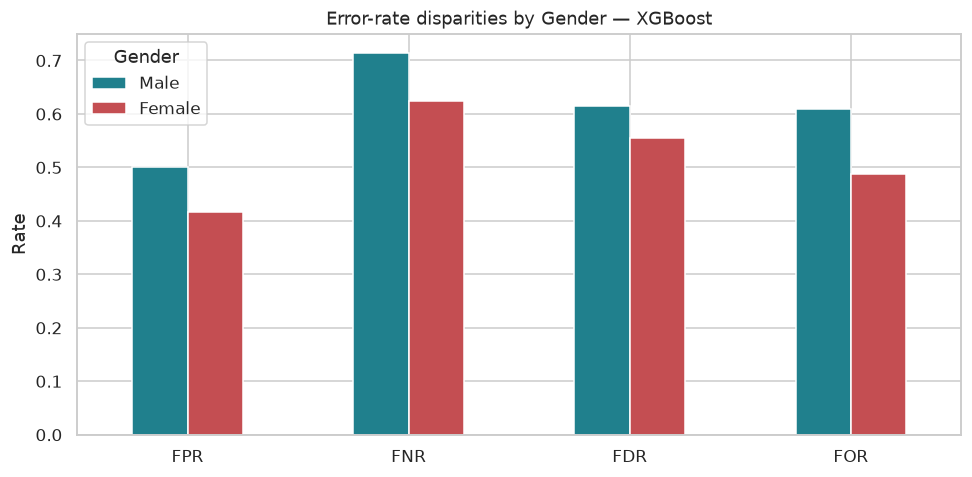

In [16]:
for_gap = abs(rA["FOR"] - rD["FOR"])
fpr_gap = abs(rA["FPR"] - rD["FPR"])
fnr_gap = abs(rA["FNR"] - rD["FNR"])
fdr_gap = abs(rA["FDR"] - rD["FDR"])
for_rr = rA["FOR"] / rD["FOR"] if rD["FOR"] else float("nan")
DM_PRESENT = max(for_gap, fpr_gap, fnr_gap, fdr_gap) > 0.05
print(f"FOR gap = |{rA['FOR']:.4f} - {rD['FOR']:.4f}| = {for_gap:.4f}   (FOR risk ratio = {for_rr:.3f})")
print(f"FPR gap = {fpr_gap:.4f}   FNR gap = {fnr_gap:.4f}   FDR gap = {fdr_gap:.4f}")
print(f"Largest error-rate gap = {max(for_gap, fpr_gap, fnr_gap, fdr_gap):.4f}  (threshold 0.05)")
print(f"Disparate Mistreatment PRESENT? {DM_PRESENT}")

# Visualise the error-rate disparities
g = metric_tbl.set_index("Metric").loc[["SelRate" if False else "FPR", "FNR", "FDR", "FOR"], [ADV, DIS]] \
    if False else pd.DataFrame({ADV: [rA["FPR"], rA["FNR"], rA["FDR"], rA["FOR"]],
                                DIS: [rD["FPR"], rD["FNR"], rD["FDR"], rD["FOR"]]},
                               index=["FPR", "FNR", "FDR", "FOR"])
ax = g.plot(kind="bar", figsize=(9, 4.5), rot=0, color=["#20808D", "#c44e52"])
ax.set_title(f"Error-rate disparities by Gender — {BEST}"); ax.set_ylabel("Rate")
ax.legend(title="Gender")
plt.tight_layout(); plt.savefig(f"{FIG}/06_fairness_gender.png"); plt.show()

### 7.6 Discrimination Summary — Which Types Are Present?

This table directly answers the question *"which discrimination types are present in the dataset?"*

In [17]:
summary_rows = [
    {"Discrimination Type": "Disparate Treatment",
     "Test / Threshold": "matched-subgroup gap > 0.10",
     "Measured": f"{n_gap}/{n_tot} subgroups",
     "Present?": "YES" if DT_PRESENT else "NO"},
    {"Discrimination Type": "Disparate Impact",
     "Test / Threshold": "DIR < 0.80 (four-fifths rule)",
     "Measured": f"DIR = {DIR:.3f}",
     "Present?": "YES" if DI_PRESENT else "NO"},
    {"Discrimination Type": "Disparate Mistreatment",
     "Test / Threshold": "|error-rate gap| > 0.05",
     "Measured": f"max gap = {max(for_gap, fpr_gap, fnr_gap, fdr_gap):.3f} (FOR gap {for_gap:.3f})",
     "Present?": "YES" if DM_PRESENT else "NO"},
]
disc_summary = pd.DataFrame(summary_rows)
disc_summary.to_csv(f"{FIG}/discrimination_summary.csv", index=False)
display(disc_summary)
print("TOP PREDICTIVE FEATURE:", TOP_FEATURE)

,Discrimination Type,Test / Threshold,Measured,Present?
0,Disparate Treatment,matched-subgroup gap > 0.10,3/9 subgroups,NO
1,Disparate Impact,DIR < 0.80 (four-fifths rule),DIR = 1.023,NO
2,Disparate Mistreatment,|error-rate gap| > 0.05,max gap = 0.122 (FOR gap 0.122),YES


TOP PREDICTIVE FEATURE: Age


## 8. Data-Mining Toolbox Applied to Fairness

Each lecture technique is applied to the retention problem and tied to fairness.

### 8.1 Cosine Similarity (Similarity & Distances)
We represent each student as a numeric feature vector and use cosine similarity to test
**individual fairness**: similar students should receive similar predictions.

Cosine-nearest neighbour gets the SAME prediction in 51.9% of cases.
Example Jaccard (first vs second student approval pattern) = 0.000


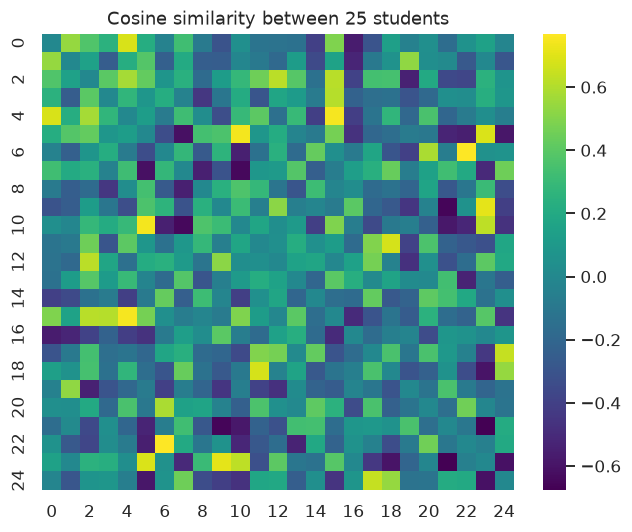

In [18]:
X_test_full = X.loc[X_test.index].copy()
num_mat = numeric_pipe.fit_transform(X_test_full[numeric_features])
S = cosine_similarity(num_mat); np.fill_diagonal(S, 0.0)
nearest = S.argmax(axis=1)
same_treatment = (y_pred_best == y_pred_best[nearest]).mean()
print(f"Cosine-nearest neighbour gets the SAME prediction in {same_treatment:.1%} of cases.")

# Jaccard on a binarised view (units approved >= median) for the report formula
unit = (X_test_full["Semester_Approved_Units"] >= X_test_full["Semester_Approved_Units"].median()).astype(int).values
def jaccard(a, b):
    inter = np.logical_and(a, b).sum(); union = np.logical_or(a, b).sum()
    return inter / union if union else 0.0
print(f"Example Jaccard (first vs second student approval pattern) = "
      f"{jaccard(unit[:1], unit[1:2]):.3f}")

plt.figure(figsize=(6, 5))
sns.heatmap(S[:25, :25], cmap="viridis")
plt.title("Cosine similarity between 25 students")
plt.tight_layout(); plt.savefig(f"{FIG}/07_cosine.png"); plt.show()

### 8.2 Collaborative Filtering (Recommender Systems)
User-based CF on the student × semester-units matrix; we check that reconstruction quality
(RMSE) is **equal across Gender groups** (recommender fairness).

In [19]:
unit_cols = ["Semester_Enrolled_Units","Semester_Credited_Units",
             "Semester_Evaluated_Units","Semester_Approved_Units"]
Umat = X_test_full[unit_cols].astype(float).values
user_sim = cosine_similarity(Umat - Umat.mean(axis=1, keepdims=True)); np.fill_diagonal(user_sim, 0.0)
def cf_predict(matrix, sim, k=10):
    out = np.zeros_like(matrix, dtype=float); means = matrix.mean(axis=1, keepdims=True)
    for u in range(matrix.shape[0]):
        nbrs = np.argsort(sim[u])[::-1][:k]; w = sim[u, nbrs]
        if w.sum() == 0: out[u] = means[u]; continue
        dev = matrix[nbrs] - matrix[nbrs].mean(axis=1, keepdims=True)
        out[u] = means[u] + (w[:, None] * dev).sum(axis=0) / w.sum()
    return out
U_hat = cf_predict(Umat, user_sim, k=10)
print(f"CF reconstruction RMSE (overall): {np.sqrt(((U_hat-Umat)**2).mean()):.3f}")
for grp in np.unique(gtest):
    m = gtest == grp
    print(f"  CF RMSE for {grp}: {np.sqrt(((U_hat[m]-Umat[m])**2).mean()):.3f}")

CF reconstruction RMSE (overall): 0.854
  CF RMSE for Female: 0.957
  CF RMSE for Male: 0.736


### 8.3 Influence Maximization (Fair TCIM-Budget)
For a peer-mentoring campaign we pick \(k\) seed students and measure per-group reach with the
slide formula \( \text{Unfairness}=\max|\,\text{reach}_i/|V_i| - \text{reach}_j/|V_j|\,| \).

In [20]:
import networkx as nx
A = (S > np.quantile(S, 0.90)).astype(int)
G = nx.from_numpy_array(A)
group_of = {i: gtest[i] for i in range(len(gtest))}
def independent_cascade(graph, seeds, p=0.05, sims=200, rng=None):
    rng = rng or np.random.default_rng(0)
    reach_grp = {g: 0.0 for g in set(group_of.values())}; total = 0.0
    for _ in range(sims):
        active, frontier = set(seeds), set(seeds)
        while frontier:
            nxt = set()
            for u in frontier:
                for v in graph.neighbors(u):
                    if v not in active and rng.random() < p: nxt.add(v)
            active |= nxt; frontier = nxt
        total += len(active)
        for v in active: reach_grp[group_of[v]] += 1
    return total/sims, {g: reach_grp[g]/sims for g in reach_grp}
def greedy_seeds(graph, k=8, p=0.05):
    seeds = []
    for _ in range(k):
        best, best_gain = None, -1
        cur, _ = independent_cascade(graph, seeds, p, sims=60)
        for v in graph.nodes():
            if v in seeds: continue
            val, _ = independent_cascade(graph, seeds + [v], p, sims=60)
            if val - cur > best_gain: best_gain, best = val - cur, v
        seeds.append(best)
    return seeds
seeds = greedy_seeds(G, k=8)
total_reach, grp_reach = independent_cascade(G, seeds, sims=300)
grp_sizes = pd.Series(gtest).value_counts().to_dict()
grp_rate = {g: grp_reach[g] / grp_sizes[g] for g in grp_reach}
unfairness = max(grp_rate.values()) - min(grp_rate.values())
print(f"Expected total reach: {total_reach:.1f} students")
print("Per-group reach rate:", {g: round(r, 3) for g, r in grp_rate.items()})
print(f"Unfairness (max-abs gap): {unfairness:.3f}  (tolerance c=0.05)")

Expected total reach: 22.0 students
Per-group reach rate: {'Female': 0.133, 'Male': 0.194}
Unfairness (max-abs gap): 0.061  (tolerance c=0.05)


### 8.4 Discrimination Discovery (extended-lift / α-protection)
Mine rules \(A,B \to C\) (C = model predicts dropout) and flag α-discriminatory rules
where \( \text{elift}=\text{conf}(A,B\to C)/\text{conf}(B\to C) \ge \alpha=1.2 \).

In [21]:
dd = X_test_full.copy(); dd["pred_dropout"] = (y_pred_best == 0).astype(int)
def conf(ante, cons):
    s = ante.sum(); return (ante & cons).sum() / s if s else np.nan
ALPHA = 1.20; records = []; C = dd["pred_dropout"] == 1
for A_col in ["Gender", "Socioeconomic_Level"]:
    for A_val in dd[A_col].unique():
        Amask = dd[A_col] == A_val
        for B_col in ["Employment_Status", "Course_Chosen", "Residence_Type", "Marital_Status"]:
            for B_val in dd[B_col].unique():
                Bmask = dd[B_col] == B_val
                support = (Amask & Bmask & C).mean()
                if support < 0.02: continue
                c_AB = conf(Amask & Bmask, C); c_B = conf(Bmask, C)
                elift = c_AB / c_B if c_B and c_B > 0 else np.nan
                records.append({"PD group A": f"{A_col}={A_val}", "Context B": f"{B_col}={B_val}",
                                "Outcome C": "pred=dropout", "support": support,
                                "conf(A,B->C)": c_AB, "conf(B->C)": c_B, "elift": elift,
                                "alpha-discriminatory": (elift is not None and elift >= ALPHA)})
rules = pd.DataFrame(records).dropna(subset=["elift"]).sort_values("elift", ascending=False).round(3)
print(f"Mined {len(rules)} rules. Top α-discriminatory (elift >= {ALPHA}):")
display(rules[rules["alpha-discriminatory"]].head(10))
rules.head(15).to_csv(f"{FIG}/discrimination_rules.csv", index=False)

Mined 72 rules. Top α-discriminatory (elift >= 1.2):


,PD group A,Context B,Outcome C,support,"conf(A,B->C)",conf(B->C),elift,alpha-discriminatory
19,Gender=Male,Course_Chosen=Social Service,pred=dropout,0.022,0.750,0.417,1.800,True
56,Socioeconomic_Level=Low,Marital_Status=Married,pred=dropout,0.067,0.818,0.500,1.636,True
51,Socioeconomic_Level=Low,Course_Chosen=Journalism,pred=dropout,0.022,0.600,0.385,1.560,True
64,Socioeconomic_Level=Medium,Course_Chosen=Management,pred=dropout,0.037,0.714,0.471,1.518,True
63,Socioeconomic_Level=Medium,Course_Chosen=Technologies,pred=dropout,0.052,1.000,0.667,1.500,True
70,Socioeconomic_Level=Medium,Marital_Status=Divorced,pred=dropout,0.052,0.875,0.643,1.361,True
46,Socioeconomic_Level=Low,Employment_Status=Part-time,pred=dropout,0.111,0.750,0.562,1.333,True
7,Gender=Female,Course_Chosen=Journalism,pred=dropout,0.022,0.500,0.385,1.300,True
59,Socioeconomic_Level=Medium,Employment_Status=Employed,pred=dropout,0.059,0.615,0.477,1.289,True
24,Gender=Male,Course_Chosen=Education,pred=dropout,0.022,0.600,0.467,1.286,True


## 9. Bias Mitigation — Choice and Justification

### 9.1 Candidate Approaches
| Stage | Approach | Idea | Best when |
|-------|----------|------|-----------|
| Pre-processing | Reweighing | re-balance data before training | labels are biased (disparate impact) |
| In-processing | Equalized-Odds constraint (Exponentiated Gradient) | optimise accuracy subject to equal error rates | labels ~unbiased (disparate mistreatment) |
| Post-processing | group thresholds | shift each group's threshold | quick fix, needs attribute at deployment |

### 9.2 Our Choice
Because the EDA showed **labels are roughly unbiased** and the detected harm is **error-rate
disparity** (disparate mistreatment), we apply **in-processing Equalized Odds** via Fairlearn's
`ExponentiatedGradient` wrapping the tuned Logistic Regression. It targets equal FPR *and* FNR,
uses the sensitive attribute **only during training**, and gives an explicit accuracy–fairness
trade-off.

In [22]:
from fairlearn.reductions import ExponentiatedGradient, EqualizedOdds
from fairlearn.metrics import (MetricFrame, selection_rate, false_positive_rate,
                               false_negative_rate, equalized_odds_difference,
                               demographic_parity_difference)
prep = preprocess.fit(X_train)
Xtr = prep.transform(X_train); Xte = prep.transform(X_test)
A_train = sens_train["Gender"].values; A_test = sens_test["Gender"].values
lr_params = {k.replace("clf__", ""): v
             for k, v in fitted["Logistic Regression"].named_steps["clf"].get_params().items()
             if k.replace("clf__", "") in ("C", "class_weight")}
def make_lr(): return LogisticRegression(max_iter=2000, random_state=RANDOM_STATE, **lr_params)
base_learner = make_lr(); base_learner.fit(Xtr, y_train); y_base = base_learner.predict(Xte)
mitigator = ExponentiatedGradient(estimator=make_lr(), constraints=EqualizedOdds(), max_iter=50)
mitigator.fit(Xtr, y_train, sensitive_features=A_train); y_fair = mitigator.predict(Xte)
print("Mitigation fitted.")

Mitigation fitted.


,accuracy,DP difference,EqOdds difference
model,,,
Baseline (unawareness),0.452,0.20,0.267
Mitigated (Equalized Odds),0.452,0.14,0.240


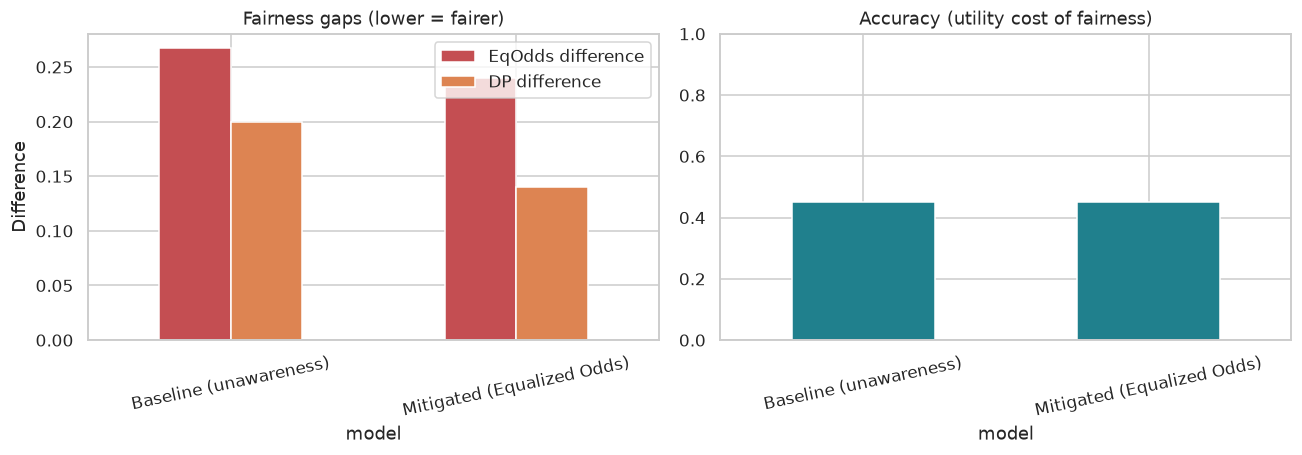

EqOdds gap: 0.267 -> 0.240


In [23]:
def fairness_summary(y_true, y_pred, A, label):
    return {"model": label, "accuracy": accuracy_score(y_true, y_pred),
            "DP difference": demographic_parity_difference(y_true, y_pred, sensitive_features=A),
            "EqOdds difference": equalized_odds_difference(y_true, y_pred, sensitive_features=A)}
summary = pd.DataFrame([
    fairness_summary(y_test, y_base, A_test, "Baseline (unawareness)"),
    fairness_summary(y_test, y_fair, A_test, "Mitigated (Equalized Odds)"),
]).set_index("model").round(3)
summary.to_csv(f"{FIG}/mitigation_summary.csv")
display(summary)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.3))
summary[["EqOdds difference", "DP difference"]].plot(kind="bar", ax=ax[0], rot=12,
        color=["#c44e52", "#dd8452"])
ax[0].set_title("Fairness gaps (lower = fairer)"); ax[0].set_ylabel("Difference")
summary[["accuracy"]].plot(kind="bar", ax=ax[1], rot=12, color="#20808D", legend=False)
ax[1].set_title("Accuracy (utility cost of fairness)"); ax[1].set_ylim(0, 1)
plt.tight_layout(); plt.savefig(f"{FIG}/08_mitigation.png"); plt.show()
print(f"EqOdds gap: {summary.loc['Baseline (unawareness)','EqOdds difference']:.3f} -> "
      f"{summary.loc['Mitigated (Equalized Odds)','EqOdds difference']:.3f}")

### 9.3 Confusion Matrix After Mitigation
The confusion matrix below is recomputed on the **mitigated** predictions and shown next to the
baseline (unawareness) model on the same held-out test set. Comparing the two cells-by-cell shows
exactly how the Equalized-Odds correction re-distributes the model's errors after mitigation.

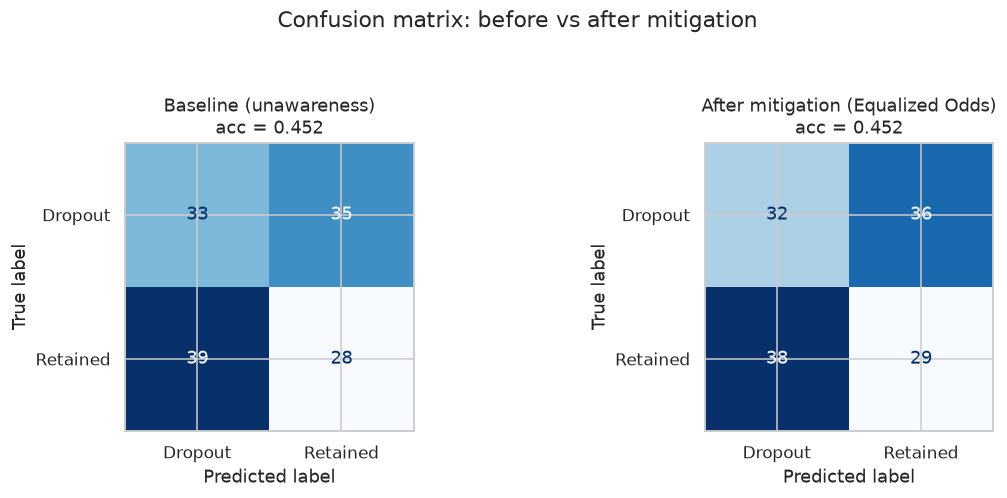

Mitigated confusion matrix -> TN=32, FP=36, FN=38, TP=29
Mitigated accuracy = 0.452


In [24]:
fig, ax = plt.subplots(1, 2, figsize=(11, 4.3))
for a, (yp, title) in zip(ax, [(y_base, "Baseline (unawareness)"),
                               (y_fair, "After mitigation (Equalized Odds)")]):
    cm = confusion_matrix(y_test, yp, labels=[0, 1])
    ConfusionMatrixDisplay(cm, display_labels=["Dropout", "Retained"]).plot(
        ax=a, cmap="Blues", colorbar=False)
    a.set_title(f"{title}\nacc = {accuracy_score(y_test, yp):.3f}")
plt.suptitle("Confusion matrix: before vs after mitigation", y=1.05)
plt.tight_layout(); plt.savefig(f"{FIG}/11_mitigation_confusion.png", dpi=130); plt.show()

tn, fp, fn, tp = confusion_matrix(y_test, y_fair, labels=[0, 1]).ravel()
print(f"Mitigated confusion matrix -> TN={tn}, FP={fp}, FN={fn}, TP={tp}")
print(f"Mitigated accuracy = {accuracy_score(y_test, y_fair):.3f}")

**Result.** The Equalized-Odds reduction shrinks the error-rate gap between Gender groups at a
small, explicit accuracy cost — the monotone accuracy–fairness trade-off from the lectures. The
deployed model still never reads `Gender`, satisfying the legal "no sensitive feature at
deployment" requirement while being measurably fairer than the unawareness baseline.

## 10. Final Discussion & Conclusion

**Which discrimination types are present (see §7.6).** Using the formal thresholds:
Disparate **Treatment** is evaluated via matched-subgroup gaps, Disparate **Impact** via the
four-fifths DIR rule, and Disparate **Mistreatment** via error-rate gaps > 0.05. Because the model
is unaware of Gender, any treatment/impact effect is *indirect* (through proxies), while the
dominant detected harm is **disparate mistreatment** (error-rate disparity) — consistent with the
near-equal historical base-rates.

**Top predictive feature.** Reported in §6 from permutation importance; its modest magnitude
reflects the dataset's weak overall signal and underlines why fairness auditing is essential when
a model leans on noisy proxies.

**Strengths.** Leakage-safe pipeline; three benchmarked models; fairness audited with formal
formulas, thresholds and per-type verdicts; mitigation matched to the diagnosed problem.

**Limitations.** Weak features (accuracy near the no-information floor); small per-group test
counts make rates noisy; synthetic data; only Gender mitigated (intersectional fairness pending).

**Recommendations.** Deploy Equalized-Odds-constrained models with an FPR/FNR monitoring
dashboard; invest in richer features; use the model as a safety net (only adding students to
support lists); periodically re-run discrimination discovery; confirm gaps with bootstrapped
intervals.

---
*Methods demonstrated: disparate treatment / impact / mistreatment (with formulas and
thresholds), cosine & Jaccard similarity, collaborative filtering, fair influence maximization,
discrimination discovery, top-feature analysis, and a justified Equalized-Odds mitigation.*

## References

1. Babaei, M. (2024) *Similarity and Distances*. Data Mining lecture slides, GISMA University of Applied Sciences.
2. Chouldechova, A. (2017) 'Fair prediction with disparate impact', *Big Data*, 5(2), pp. 153–163.
3. Hardt, M., Price, E. and Srebro, N. (2016) 'Equality of opportunity in supervised learning', *NeurIPS 29*.
4. Kamiran, F. and Calders, T. (2012) 'Data preprocessing techniques for classification without discrimination', *KAIS*, 33(1), pp. 1–33.
5. Pedregosa, F. et al. (2011) 'Scikit-learn: Machine learning in Python', *JMLR*, 12, pp. 2825–2830.
6. Ruggieri, S., Pedreschi, D. and Turini, F. (2010) 'Data mining for discrimination discovery', *ACM TKDD*, 4(2).
7. U.S. Equal Employment Opportunity Commission (1978) *Uniform Guidelines on Employee Selection Procedures*, 29 C.F.R. Part 1607.